# Credit Card Default Classification
M.Tech (AIML/DSE) — Machine Learning

Predicts whether a credit card client will default on their payment next month, based on demographic details, credit limit, and the last 6 months of billing and repayment history. Binary classification (`Default`: Yes/No).

**Dataset:** *Default of Credit Card Clients*, UCI Machine Learning Repository (Yeh & Lien, 2009) — 30,000 credit card clients from a Taiwanese bank, 23 predictive features + 1 target column.

**Notebook structure:**
1. Load and clean the data
2. Train/test split (test split exported as `test_data.csv`)
3. Build a shared preprocessing pipeline
4. Train 5 classification models: Logistic Regression, Decision Tree, kNN, Naive Bayes, Random Forest (Ensemble)
5. Evaluate each model: Accuracy, AUC, Precision, Recall, F1, MCC
6. Save each trained model to `model/*.pkl`

In [1]:
# Imports
import json
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
sns.set_style("whitegrid")
print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Load the data
`credit_raw.csv` sits in the same folder as this notebook. Source: UCI Machine Learning Repository, "Default of Credit Card Clients".

In [2]:
df = pd.read_csv("credit_raw.csv")
print("Shape:", df.shape)
df.head()


Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

## 2. Clean the data
A few cleaning steps applied to the raw file:
1. `ID` is a unique identifier with no predictive value — dropped.
2. The raw file names the repayment-status columns `PAY_0, PAY_2, PAY_3, ..., PAY_6` (skipping `PAY_1`) — renamed `PAY_0` to `PAY_1` so all six months are consistently numbered.
3. `EDUCATION` and `MARRIAGE` contain a handful of category codes not documented in the official UCI codebook (`EDUCATION`: 0, 5, 6; `MARRIAGE`: 0). Instead of deleting those ~400 rows, they're folded into the existing "others" bucket (`EDUCATION=4`, `MARRIAGE=3`), keeping the full 30,000-row sample.
4. Target column renamed to `Default` (1 = will default next month, 0 = will not).

In [4]:
df = df.drop(columns=["ID"])
df = df.rename(columns={"PAY_0": "PAY_1"})

print("EDUCATION value counts before cleaning:")
print(df["EDUCATION"].value_counts().sort_index())
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

print("\nMARRIAGE value counts before cleaning:")
print(df["MARRIAGE"].value_counts().sort_index())
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

df = df.rename(columns={"default.payment.next.month": "Default"})

print(f"\nFinal shape -> Instances: {df.shape[0]}, Features: {df.shape[1]-1}")
df["Default"].value_counts(normalize=True).rename("proportion")


EDUCATION value counts before cleaning:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE value counts before cleaning:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Final shape -> Instances: 30000, Features: 23


Default
0    0.7788
1    0.2212
Name: proportion, dtype: float64

### Class balance
The dataset is moderately imbalanced (~22% will default). Accuracy alone can look good even on a weak model here, so MCC and F1 are tracked alongside it for a fuller picture.

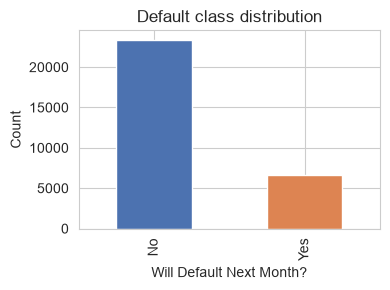

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
df["Default"].map({1: "Yes", 0: "No"}).value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Default class distribution")
ax.set_xlabel("Will Default Next Month?")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 3. Train / test split
An 80/20 stratified split keeps the default ratio consistent in both sets. The test split is exported as `test_data.csv`, which is also the file uploaded to the Streamlit app for live evaluation — so results shown there match what's reported here.

In [6]:
X = df.drop(columns=["Default"])
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

test_export = X_test.copy()
test_export["Default"] = y_test.map({1: "Yes", 0: "No"})
test_export.to_csv("test_data.csv", index=False)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print("Saved test_data.csv")


Train size: 24000  |  Test size: 6000
Saved test_data.csv


## 4. Shared preprocessing pipeline
- **Numeric / ordinal columns** (`LIMIT_BAL`, `AGE`, the 6 `PAY_*` repayment-status columns, the 6 `BILL_AMT*` columns, the 6 `PAY_AMT*` columns — 20 columns total) → `StandardScaler`, since distance/gradient-based models (kNN, Logistic Regression) are sensitive to feature scale.
- **Categorical columns** (`SEX`, `EDUCATION`, `MARRIAGE` — 3 columns) → `OneHotEncoder`, since these are unordered category codes, not true numeric quantities.

Wrapping this in a `ColumnTransformer` and then a `Pipeline` with the classifier means each saved `.pkl` file includes both preprocessing and the model — the app can call `.predict()` directly on raw uploaded CSV data without reimplementing any preprocessing logic.

In [7]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
])

print(f"{len(numeric_cols)} numeric columns:", numeric_cols)
print(f"{len(categorical_cols)} categorical columns:", categorical_cols)


20 numeric columns: ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
3 categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']


## 5. Classification models
| # | Model | Notes |
|---|-------|-------|
| 1 | Logistic Regression | Linear baseline, interpretable coefficients |
| 2 | Decision Tree | Non-linear, captures interactions, prone to overfitting (depth capped at 8) |
| 3 | kNN | Distance-based, needs the scaled features from the pipeline |
| 4 | Naive Bayes (Gaussian) | Fast probabilistic baseline; assumes feature independence |
| 5 | Random Forest (Ensemble) | Bagged trees, usually the strongest of the five |

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
}

filename_map = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "kNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest (Ensemble)": "random_forest.pkl",
}
list(models.keys())


['Logistic Regression',
 'Decision Tree',
 'kNN',
 'Naive Bayes',
 'Random Forest (Ensemble)']

## 6. Train, evaluate, and save each model
For each model: fit the full pipeline, predict on the held-out test set, compute Accuracy, AUC, Precision, Recall, F1, and MCC, and save the fitted pipeline to `model/<name>.pkl` with `joblib`.

In [9]:
os.makedirs("model", exist_ok=True)

results = []
fitted_pipes = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipes[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    }
    results.append(metrics)

    joblib.dump(pipe, f"model/{filename_map[name]}")
    print(f"Trained & saved: {name}")

results_df = pd.DataFrame(results)
results_df


Trained & saved: Logistic Regression
Trained & saved: Decision Tree
Trained & saved: kNN
Trained & saved: Naive Bayes
Trained & saved: Random Forest (Ensemble)


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8088,0.7100,0.6923,0.2442,0.3610,0.3302
1,Decision Tree,0.8157,0.7441,0.6471,0.3662,0.4678,0.3882
2,kNN,0.8088,0.7305,0.6236,0.3421,0.4418,0.3603
3,Naive Bayes,0.6607,0.7248,0.3590,0.6805,0.4701,0.2822
4,Random Forest (Ensemble),0.8167,0.7752,0.6601,0.3527,0.4597,0.3871


Trained & saved: kNN
Trained & saved: Naive Bayes


Trained & saved: Random Forest (Ensemble)


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8088,0.7100,0.6923,0.2442,0.3610,0.3302
1,Decision Tree,0.8157,0.7441,0.6471,0.3662,0.4678,0.3882
2,kNN,0.8088,0.7304,0.6236,0.3421,0.4418,0.3603
3,Naive Bayes,0.6607,0.7248,0.3590,0.6805,0.4701,0.2822
4,Random Forest (Ensemble),0.8167,0.7752,0.6601,0.3527,0.4597,0.3871


## 7. Comparison table

In [10]:
results_df.to_csv("model/metrics_table.csv", index=False)
with open("model/metrics.json", "w") as f:
    json.dump(results, f, indent=2)

results_df.set_index("Model").style.background_gradient(cmap="Blues", axis=0)


,Accuracy,AUC,Precision,Recall,F1,MCC
Model,,,,,,
Logistic Regression,0.808800,0.710000,0.692300,0.244200,0.361000,0.330200
Decision Tree,0.815700,0.744100,0.647100,0.366200,0.467800,0.388200
kNN,0.808800,0.730500,0.623600,0.342100,0.441800,0.360300
Naive Bayes,0.660700,0.724800,0.359000,0.680500,0.470100,0.282200
Random Forest (Ensemble),0.816700,0.775200,0.660100,0.352700,0.459700,0.387100


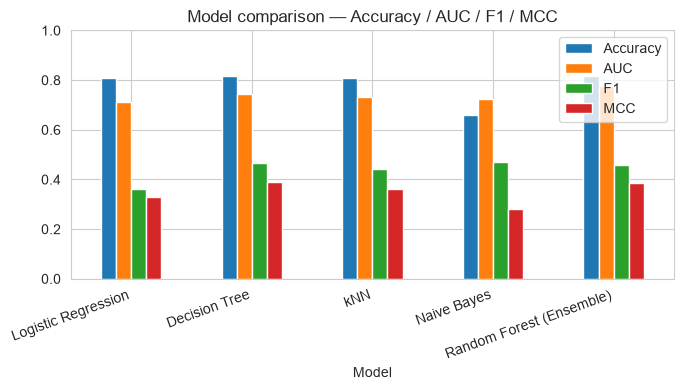

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df.set_index("Model")[["Accuracy", "AUC", "F1", "MCC"]].plot(kind="bar", ax=ax)
ax.set_title("Model comparison — Accuracy / AUC / F1 / MCC")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 8. Confusion matrix — Random Forest
Random Forest is the top performer on Accuracy/AUC. The Streamlit app can generate this same view for any of the 5 models on any uploaded CSV.

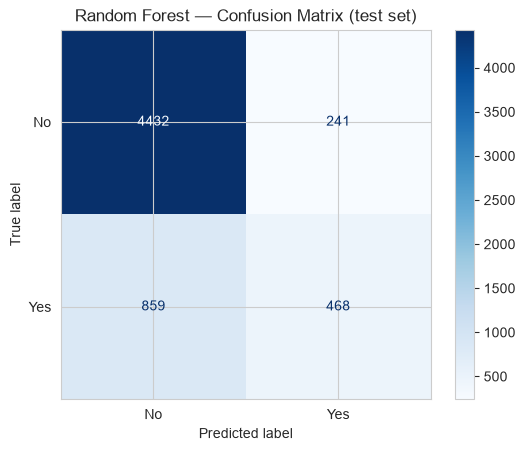

              precision    recall  f1-score   support

          No       0.84      0.95      0.89      4673
         Yes       0.66      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [12]:
best_pipe = fitted_pipes["Random Forest (Ensemble)"]
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix (test set)")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["No", "Yes"]))


## Observations
- **Random Forest** gives the best overall balance of Accuracy (0.8167) and AUC (0.7752) — bagging 300 trees smooths out the noise a single tree overfits to.
- **Decision Tree** is a close second on Accuracy/AUC and has the best Recall among the higher-accuracy models, but is more prone to overfitting the specific training split than the Random Forest.
- **Naive Bayes** has by far the highest Recall (0.6805) — it catches most future defaulters — but the lowest Accuracy and Precision. Its independence assumption is violated here (the six `BILL_AMT*` columns are highly correlated with each other, as are the six `PAY_*` columns), which pushes it toward flagging far more clients as risky than actually are. Still useful for a bank that would rather over-flag than miss a defaulter.
- **Logistic Regression** has the highest Precision (0.6923) — when it predicts default, it's usually right — but the lowest Recall of the top-4 models, meaning it misses a lot of actual defaulters. A classic precision/recall trade-off from a linear decision boundary being conservative on an imbalanced target.
- **kNN** sits in the middle across all metrics; sensitive to scaling (already applied) and somewhat affected by the higher dimensionality after one-hot encoding.
- Every model's Recall is much lower than Precision — defaulters are the harder class to catch, expected on a dataset where only ~22% of clients default.

## Summary
All 5 trained pipelines are saved in `model/`. To explore results interactively:
```
streamlit run app.py
```
Upload `test_data.csv` to reproduce these metrics in the app.